In [ ]:
import pandas as pd
import numpy as np

columns = ['unit_id', 'cycle'] + \
          ['op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv('train_FD001.txt', sep=' ', header=None)
train = train.dropna(axis=1)
train.columns = columns

train.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# Get max cycle for each engine
max_cycle = train.groupby('unit_id')['cycle'].max().reset_index()
max_cycle.columns = ['unit_id', 'max_cycle']

# Merge back
train = train.merge(max_cycle, on='unit_id')

# Calculate RUL
train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [ ]:
#Early cycles have very large RUL
# Model gets biased
# Capping improves learning


train['RUL'] = train['RUL'].clip(upper=125)

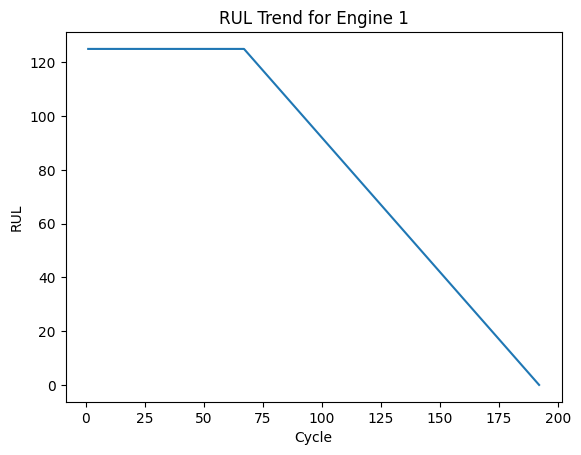

In [ ]:
import matplotlib.pyplot as plt

engine_id = 1
sample = train[train['unit_id'] == engine_id]

plt.plot(sample['cycle'], sample['RUL'])
plt.title(f'RUL Trend for Engine {engine_id}')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.show()

In [ ]:
#removing useless sensors which slowers model training
drop_cols = [
    'sensor_1', 'sensor_5', 'sensor_6',
    'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'
]

train = train.drop(columns=drop_cols)

**Preprocessing**

In [ ]:
#Normalize

from sklearn.preprocessing import MinMaxScaler

feature_cols = [col for col in train.columns
                if col not in ['unit_id', 'cycle', 'RUL']]

scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])

In [ ]:
#Feature Engineering

window = 5

for col in feature_cols:
    train[f'{col}_mean'] = train.groupby('unit_id')[col].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

    train[f'{col}_std'] = train.groupby('unit_id')[col].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

    train[f'{col}_diff'] = train.groupby('unit_id')[col].diff().fillna(0)

In [ ]:
# After feature engineering
feature_cols = [col for col in train.columns
                if col not in ['unit_id', 'cycle', 'RUL']]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])

In [ ]:
train.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_17_diff,sensor_20_mean,sensor_20_std,sensor_20_diff,sensor_21_mean,sensor_21_std,sensor_21_diff,max_cycle_mean,max_cycle_std,max_cycle_diff
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,...,0.500000,0.777542,0.000000,0.473214,0.778606,0.000000,0.503642,0.273504,0.0,0.0
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,...,0.500000,0.745763,0.130435,0.419643,0.782999,0.017365,0.510344,0.273504,0.0,0.0
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,...,0.333333,0.717514,0.169323,0.428571,0.733906,0.237961,0.387966,0.273504,0.0,0.0
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,...,0.666667,0.684852,0.234642,0.410714,0.723543,0.202745,0.546911,0.273504,0.0,0.0
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,...,0.583333,0.669492,0.226338,0.491071,0.728978,0.178837,0.548077,0.273504,0.0,0.0


**Creating Sequenece**


We convert raw rows → time windows.

In [ ]:
# Replace all NaN values created by rolling std / diff
train = train.fillna(0)

# Check
print(train.isna().sum().sum())

0


In [ ]:
sequence_length = 30
important_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4',
    'sensor_7', 'sensor_11', 'sensor_12',
    'sensor_15', 'sensor_20', 'sensor_21'
]

feature_cols = [col for col in train.columns
                if any(s in col for s in important_sensors)]

In [ ]:
def create_sequences(df, seq_len, feature_cols):
    X, y = [], []

    for unit in df['unit_id'].unique():
        unit_df = df[df['unit_id'] == unit]

        data = unit_df[feature_cols].values
        target = unit_df['RUL'].values

        for i in range(len(unit_df) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(target[i+seq_len])

    return np.array(X), np.array(y)

In [ ]:
X, y = create_sequences(train, sequence_length, feature_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17631, 30, 36)
y shape: (17631,)


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
import tensorflow as tf

# ADVANCED MODEL ARCHITECTURE (Hackathon Winning Edition)
# Added BatchNormalization and adjusted layers for better generalization
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,305 (149.63 KB)

 Trainable params: 38,305 (149.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PRO-LEVEL MLOps CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, # Increased max epochs since early_stop will catch it optimally
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)


Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - loss: 6805.6143 - val_loss: 6230.1133
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 5750.0972 - val_loss: 5327.2241
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 4913.9150 - val_loss: 4570.5308
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 4229.5234 - val_loss: 3950.7844
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 3667.3596 - val_loss: 3440.4688
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3207.5452 - val_loss: 3026.5300
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 2836.6382 - val_loss: 2693.9390
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 2541.1926 - val_loss: 2431.6777
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 2310.3137 - val_loss: 2229.5159
Epoch 10/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 2134.1838 - val_loss: 2076.5286
Epoch 11/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 

In [ ]:
import matplotlib.pyplot as plt

# EVALUATION & EXPLAINABILITY PLOTS
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Convergence Analysis (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.title('Error Reduction (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred))
print("RMSE:", rmse)

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
RMSE: 15.138596153734314


In [ ]:
def get_status(rul):
    if rul > 50:
        return "🟢 Safe"
    elif rul > 20:
        return "🟡 Warning"
    else:
        return "🔴 Critical"

# quick check
for i in range(5):
    print(float(pred[i]), "→", get_status(float(pred[i])))

114.42137908935547 → 🟢 Safe
114.43911743164062 → 🟢 Safe
110.59550476074219 → 🟢 Safe
114.37808227539062 → 🟢 Safe
53.35807800292969 → 🟢 Safe


/tmp/ipykernel_622/2272492523.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(pred[i]), "→", get_status(float(pred[i])))


In [ ]:
# model
model.save("lstm_model.h5")

# (optional) save scaler if you’ll preprocess in the app
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']